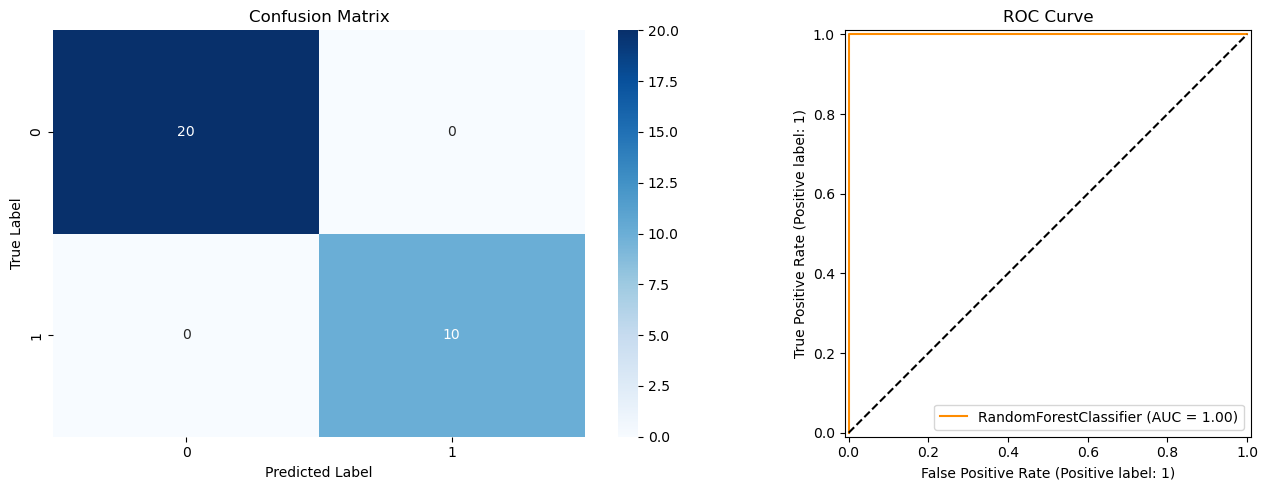

Model Accuracy: 100.00%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, RocCurveDisplay, accuracy_score
from sklearn.datasets import load_iris

# 1. Load Dataset
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# For visualization purposes, we'll focus on a binary classification (Species 0 vs Not 0)
# This allows us to generate a clean ROC Curve easily.
df['binary_target'] = (df['target'] == 0).astype(int)

# 2. Split Features and Target
X = df.drop(['target', 'binary_target'], axis=1)
y = df['binary_target']

# 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Training (Random Forest Example)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Predictions
y_pred = model.predict(X_test)

# --- 5. Performance Visualization ---

# Setup plotting area
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# A. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

# B. ROC Curve
RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax[1], color='darkorange')
ax[1].plot([0, 1], [0, 1], 'k--') # Diagonal baseline
ax[1].set_title('ROC Curve')

plt.tight_layout()
plt.show()

# 6. Print Accuracy Metrics
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))